# 1. Linear Regression

The baseline every other model has to beat.

Ordinary least squares assumes AQI is a weighted sum of the weather features. That
is almost certainly too simple — smog formation has thresholds, and heat and
stagnation interact rather than add — but a linear fit is fast, fully
interpretable, and sets the bar. If a far more flexible model only ties it, that
flexibility is not buying anything.

The features are standardized first. This does not change the predictions at all
for OLS, but it puts every coefficient in the same units (AQI points per standard
deviation), which makes them directly comparable.

## Setup

Loads the shared split written by `notebooks/build_modeling_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

print(f"train: {X_train.shape}  {meta['train_range'][0]} -> {meta['train_range'][1]}")
print(f"test:  {X_test.shape}  {meta['test_range'][0]} -> {meta['test_range'][1]}")
print(f"target: {meta['target']}  |  {meta['n_features']} features")

train: (2554, 37)  2016-01-04 -> 2022-12-31
test:  (1095, 37)  2023-01-01 -> 2025-12-30
target: daily_aqi  |  37 features


## Fitting

No hyperparameters to tune, so this is a single fit on the full training set.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAME = 'Linear Regression'

best = Pipeline([
    ('scale', StandardScaler()),
    ('model', LinearRegression()),
])
best.fit(X_train, y_train)

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params={'fit_intercept': True},
                  notes='OLS baseline on standardized features')

=== Linear Regression ===
metric           train      test
RMSE            24.551    24.007
MAE             18.447    17.879
R2               0.560     0.646
MAPE %          21.311    21.067
within10 %      36.805    38.265

overfit gap (test RMSE - train RMSE): -0.544
saved -> models/results/linear_regression.json


## Diagnostics

Three views of the same test predictions: how they line up against
truth, whether the errors are patterned or random, and how the model tracks the
actual 2023–2025 series day by day.

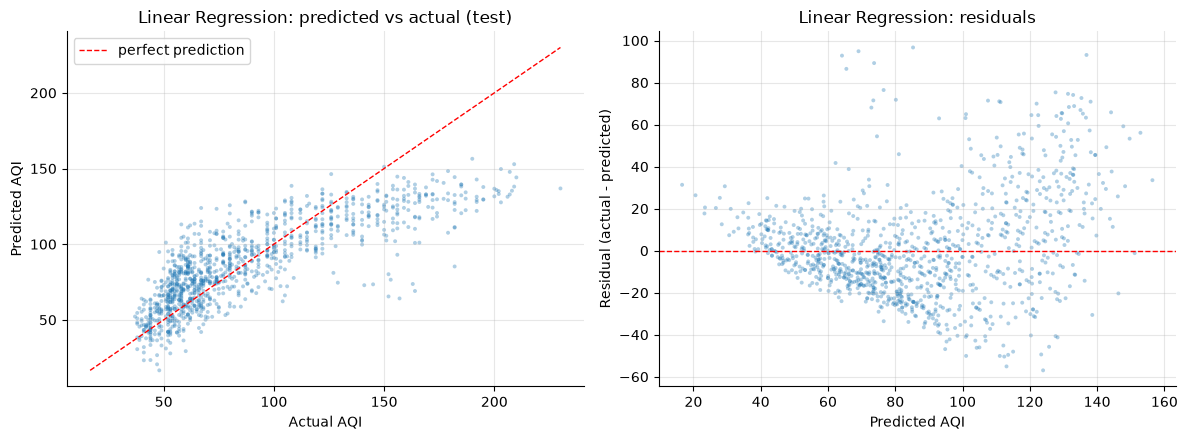

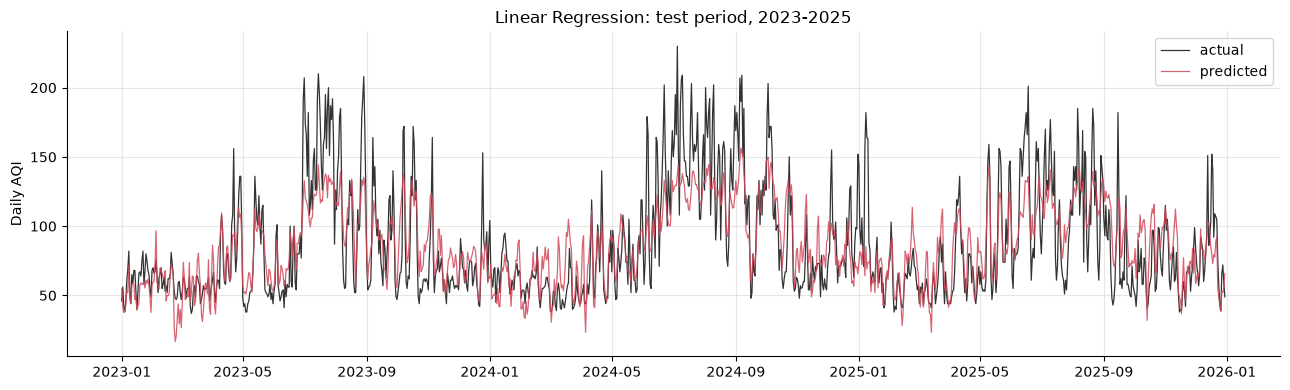

In [3]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## Reading the coefficients

Because the inputs were standardized, each coefficient is "AQI points per one
standard deviation of this feature, holding the others fixed." The signs are the
part worth checking: they should agree with the physics.

One caution — the temperature features are heavily correlated with each other, so
OLS splits credit among them somewhat arbitrarily. Individual temperature
coefficients are not trustworthy in isolation; the block as a whole is.

intercept (mean AQI): 89.37

Top 15 coefficients by magnitude (AQI points per std dev):
t2m_mean           54.39
t2m_mean_roll3     17.56
t2m_min           -14.28
t2m_max           -10.28
qv2m_mean          -8.70
wind_dir_sin       -6.86
t2m_max_roll3      -6.35
t2m_max_lag1       -5.00
wind_speed_max     -4.96
t2m_mean_lag1      -4.74
u10m_mean          -4.59
t2m_max_lag3       -3.97
wind_speed_mean     3.40
t2m_max_lag2       -3.23
qv2m_mean_roll3    -3.11


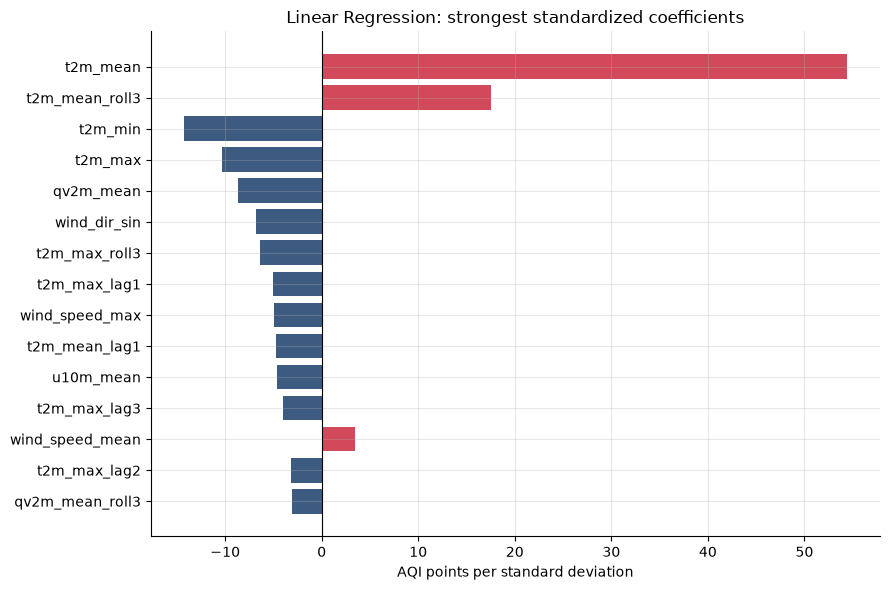

In [4]:
coefs = pd.Series(best.named_steps['model'].coef_, index=X_train.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

print(f'intercept (mean AQI): {best.named_steps["model"].intercept_:.2f}\n')
print('Top 15 coefficients by magnitude (AQI points per std dev):')
print(top.head(15).round(2).to_string())

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 6))
    sel = top.head(15)[::-1]
    ax.barh(sel.index, sel.values,
            color=['#d1495b' if v > 0 else '#3d5a80' for v in sel.values])
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('AQI points per standard deviation')
    ax.set_title('Linear Regression: strongest standardized coefficients')
    plt.tight_layout(); plt.show()

## What this told us

**Test RMSE 24.0, R² 0.646.** Weather alone explains about 65% of the day-to-day
variance in LA's AQI — a genuinely useful result for a model this simple, and the
number every other model is measured against.

The overfit gap is *negative* (−0.54): the model scores slightly better on
2023–2025 than on the years it trained on. That is not a mistake. It means OLS is
underfitting — it is nowhere near flexible enough to memorize the training years —
and the test period happens to be marginally cleaner air.

**The coefficients are not physically readable, and this is the lesson.**
`t2m_mean` comes out at +54.4 AQI points per standard deviation while `t2m_min`
(−14.3) and `t2m_max` (−10.3) come out *negative*. Read literally that says a
hotter afternoon lowers AQI, which is false. It is the multicollinearity warned
about above: the temperature features correlate with each other at well over 0.9,
so OLS can hand one of them a huge positive weight and cancel it with negatives on
the others without changing the fit. The temperature block *as a whole* is strongly
positive; no single coefficient inside it means anything on its own.

Practical read: fine as a baseline and as a variance-explained number, unusable as
an explanation of which weather variable matters most. The permutation importances
in notebooks 02 and 03 answer that question properly.